In [22]:
from google.colab import files
uploaded = files.upload()

Saving Iris.csv to Iris (1).csv


In [23]:
import pandas as pd
import numpy as np

In [24]:
df = pd.read_csv(next(iter(uploaded)))

print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:", df.shape)

First 5 Rows:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Dataset Shape: (150, 6)


In [25]:
print(df.isnull().sum())

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [26]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Species"] = encoder.fit_transform(df["Species"])

print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Species
0   1            5.1           3.5            1.4           0.2        0
1   2            4.9           3.0            1.4           0.2        0
2   3            4.7           3.2            1.3           0.2        0
3   4            4.6           3.1            1.5           0.2        0
4   5            5.0           3.6            1.4           0.2        0


In [27]:
from sklearn.model_selection import train_test_split

X = df.drop(["Species","Id"], axis=1)
y = df["Species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [28]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [29]:
predictions = model.predict(X_test)

print(predictions)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [30]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


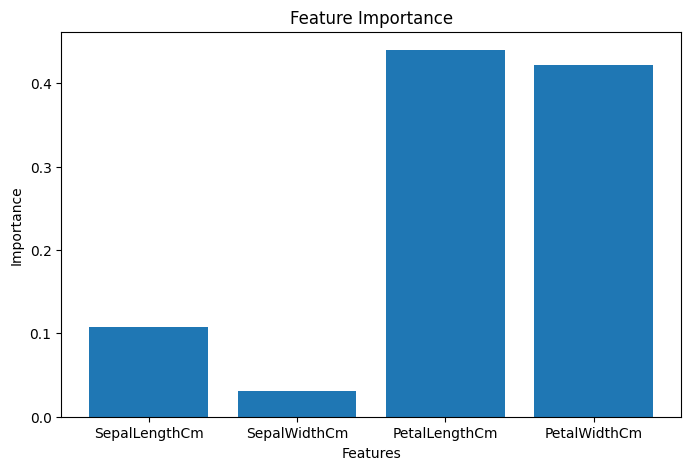

In [33]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.figure(figsize=(8,5))
plt.bar(X.columns, importance)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [34]:
sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(sample)

print("Predicted Class:", encoder.inverse_transform(prediction))

Predicted Class: ['Iris-setosa']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [35]:
!pip install shap

In [36]:
import shap

In [37]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

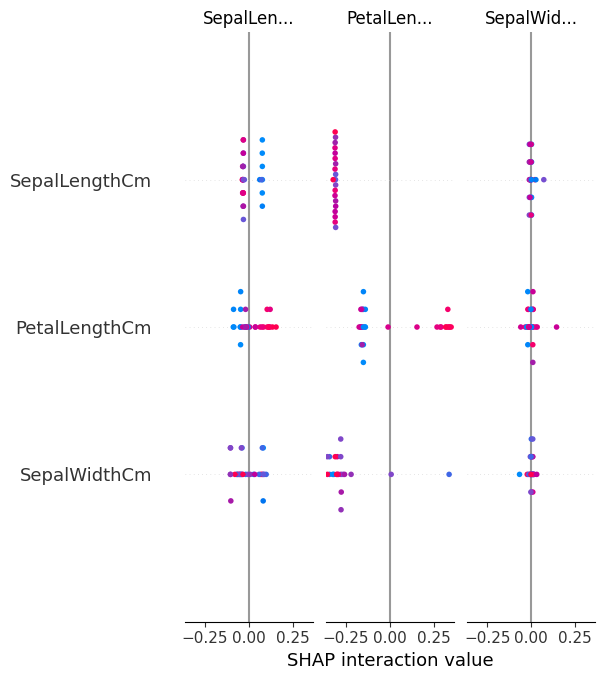

In [38]:
shap.summary_plot(shap_values, X_test)

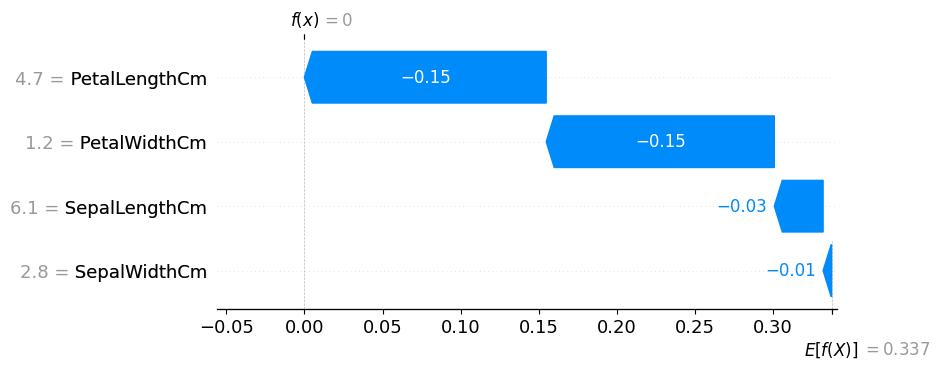

In [40]:
sample = X_test.iloc[[0]]

shap_values = explainer(sample)

# Show explanation for the first sample and first class
shap.plots.waterfall(shap_values[0, :, 0])

## Fairness Analysis

The Iris dataset contains only flower measurements and does not include sensitive attributes such as gender, race, or age. Therefore, fairness analysis across sensitive groups cannot be performed. In real-world applications, fairness metrics should be evaluated using datasets containing protected attributes.

## Bias Mitigation Recommendations

- Use balanced datasets during model training.
- Remove or carefully evaluate sensitive attributes if present.
- Regularly monitor fairness metrics.
- Use explainable AI techniques such as SHAP or LIME.
- Retrain the model if significant bias is detected.

## Model Interpretation

The Random Forest classifier achieved high accuracy on the Iris dataset. Feature importance analysis indicates that Petal Length and Petal Width contribute the most to model predictions. SHAP analysis explains how each feature influences predictions globally and locally. Since the Iris dataset contains no protected attributes, fairness analysis could not be performed.

## Conclusion

The Random Forest model successfully classified Iris flower species with high accuracy. Feature importance and SHAP explainability improved model transparency by showing how features influenced predictions. Although fairness analysis was not applicable due to the absence of sensitive attributes, appropriate bias mitigation strategies were discussed.